<a href="https://colab.research.google.com/github/letruc271193-dot/btvn/blob/main/btap2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.5 MB/s eta 0:00:00
====== KẾT QUẢ MÔ PHỎNG HỆ THỐNG GRABBIKE ======
Mức Giá cước tính toán: 92.22 % (Quy đổi theo hệ số giá)
Mức Điểm thưởng tính toán: 88.33 / 100 điểm


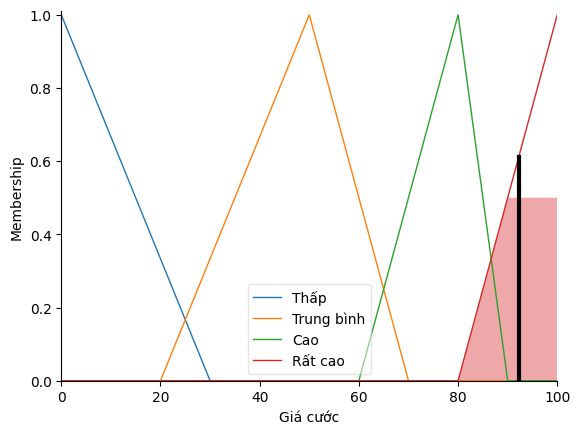

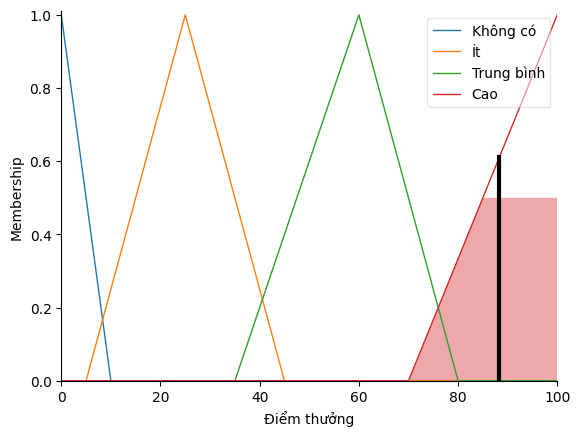

In [1]:
#2.11
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Khoảng cách (Distance): 0 - 50 km
distance = ctrl.Antecedent(np.arange(0, 51, 1), 'Khoảng cách')
distance['Ngắn'] = fuzz.trimf(distance.universe, [0, 0, 3])
distance['Trung bình'] = fuzz.trimf(distance.universe, [2, 5, 8])
distance['Dài'] = fuzz.trimf(distance.universe, [6, 13, 20])
distance['Rất xa'] = fuzz.trapmf(distance.universe, [15, 25, 50, 50]) # Dùng hình thang cho khoảng rộng

# Tình trạng giao thông (Traffic): 0 - 100 %
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'Lưu lượng giao thông')
traffic['Thấp'] = fuzz.trimf(traffic.universe, [0, 0, 30])
traffic['Trung bình'] = fuzz.trimf(traffic.universe, [20, 45, 70])
traffic['Cao'] = fuzz.trimf(traffic.universe, [60, 100, 100])

# Mức cầu (Demand): 0 - 100 %
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'Nhu cầu')
demand['Thấp'] = fuzz.trimf(demand.universe, [0, 0, 30])
demand['Trung bình'] = fuzz.trimf(demand.universe, [20, 45, 70])
demand['Cao'] = fuzz.trimf(demand.universe, [60, 100, 100])

# Điều kiện khí hậu (Weather): Giả sử thang điểm 0 - 10 (0 là rất tốt, 10 là bão)
weather = ctrl.Antecedent(np.arange(0, 11, 1), 'Thời tiết')
weather['Tốt'] = fuzz.trimf(weather.universe, [0, 0, 4])
weather['Trung bình'] = fuzz.trimf(weather.universe, [3, 5, 7])
weather['Xấu'] = fuzz.trimf(weather.universe, [6, 10, 10])

# Đánh giá của khách hàng (Rating): 1.0 - 5.0
rating = ctrl.Antecedent(np.arange(1.0, 5.1, 0.1), 'Đánh giá')
rating['Kém'] = fuzz.trimf(rating.universe, [1.0, 1.0, 2.5])
rating['Trung bình'] = fuzz.trimf(rating.universe, [2.0, 3.0, 4.0])
rating['Tốt'] = fuzz.trimf(rating.universe, [3.5, 5.0, 5.0])

# Đúng giờ (Punctuality): 0 - 100 %
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'Đúng giờ')
punctuality['Trễ'] = fuzz.trimf(punctuality.universe, [0, 0, 50])
punctuality['Đúng giờ'] = fuzz.trimf(punctuality.universe, [40, 60, 80])
punctuality['Sớm'] = fuzz.trimf(punctuality.universe, [70, 100, 100])


# Giá đi xe (Price): Giả sử thang % hoặc hệ số giá 0 - 100
price = ctrl.Consequent(np.arange(0, 101, 1), 'Giá cước')
price['Thấp'] = fuzz.trimf(price.universe, [0, 0, 30])
price['Trung bình'] = fuzz.trimf(price.universe, [20, 50, 70])
price['Cao'] = fuzz.trimf(price.universe, [60, 80, 90])
price['Rất cao'] = fuzz.trimf(price.universe, [80, 100, 100])

# Điểm thưởng (Bonus): Giả sử thang 0 - 100 điểm
bonus = ctrl.Consequent(np.arange(0, 101, 1), 'Điểm thưởng')
bonus['Không có'] = fuzz.trimf(bonus.universe, [0, 0, 10])
bonus['Ít'] = fuzz.trimf(bonus.universe, [5, 25, 45])
bonus['Trung bình'] = fuzz.trimf(bonus.universe, [35, 60, 80])
bonus['Cao'] = fuzz.trimf(bonus.universe, [70, 100, 100])



rules = [
    # Nhóm luật về Giá cước
    ctrl.Rule(distance['Ngắn'] & traffic['Thấp'] & demand['Thấp'], price['Thấp']),
    ctrl.Rule(distance['Ngắn'] & traffic['Trung bình'] & demand['Cao'], price['Trung bình']),
    ctrl.Rule(distance['Trung bình'] & traffic['Cao'] & demand['Cao'], price['Cao']),
    ctrl.Rule(distance['Dài'] & traffic['Trung bình'] & weather['Tốt'], price['Trung bình']),
    ctrl.Rule(distance['Dài'] & traffic['Cao'] & weather['Xấu'], price['Rất cao']),
    ctrl.Rule(distance['Rất xa'] & traffic['Cao'] & demand['Cao'], price['Rất cao']),
    ctrl.Rule(distance['Trung bình'] & traffic['Thấp'] & demand['Thấp'], price['Trung bình']),
    ctrl.Rule(distance['Ngắn'] & traffic['Cao'] & weather['Xấu'], price['Cao']),
    ctrl.Rule(distance['Rất xa'] & weather['Xấu'], price['Rất cao']),
    ctrl.Rule(distance['Trung bình'] & traffic['Trung bình'] & weather['Trung bình'], price['Trung bình']),


    ctrl.Rule(rating['Tốt'] & punctuality['Sớm'], bonus['Cao']),
    ctrl.Rule(rating['Trung bình'] & punctuality['Đúng giờ'], bonus['Trung bình']),
    ctrl.Rule(rating['Kém'] & punctuality['Trễ'], bonus['Không có']),
    ctrl.Rule(distance['Dài'] & traffic['Cao'] & punctuality['Đúng giờ'], bonus['Cao']),
    ctrl.Rule(distance['Trung bình'] & traffic['Trung bình'] & rating['Tốt'], bonus['Trung bình']),
    ctrl.Rule(rating['Kém'] & punctuality['Trễ'], bonus['Không có']), # Luật 16 lặp lại nội dung của 13
    ctrl.Rule(distance['Rất xa'] & weather['Xấu'] & rating['Tốt'], bonus['Cao']),
    ctrl.Rule(distance['Ngắn'] & rating['Trung bình'] & punctuality['Đúng giờ'], bonus['Ít']),
    ctrl.Rule(distance['Dài'] & traffic['Cao'] & punctuality['Trễ'], bonus['Ít']),
    ctrl.Rule(distance['Trung bình'] & weather['Trung bình'] & rating['Tốt'], bonus['Trung bình'])
]



grab_ctrl = ctrl.ControlSystem(rules)
grab_sim = ctrl.ControlSystemSimulation(grab_ctrl)


grab_sim.input['Khoảng cách'] = 10
grab_sim.input['Lưu lượng giao thông'] = 80
grab_sim.input['Nhu cầu'] = 90
grab_sim.input['Thời tiết'] = 8
grab_sim.input['Đánh giá'] = 4.8
grab_sim.input['Đúng giờ'] = 60

grab_sim.compute()


print("====== KẾT QUẢ MÔ PHỎNG HỆ THỐNG GRABBIKE ======")
print(f"Mức Giá cước tính toán: {grab_sim.output['Giá cước']:.2f} % (Quy đổi theo hệ số giá)")
print(f"Mức Điểm thưởng tính toán: {grab_sim.output['Điểm thưởng']:.2f} / 100 điểm")


price.view(sim=grab_sim)
bonus.view(sim=grab_sim)

====== KẾT QUẢ MÔ PHỎNG CHIẾT KHẤU SHOPEE ======
Tỷ lệ chiết khấu đề xuất: 55.00 %
(Sách kỳ vọng mức chiết khấu sẽ rơi vào khoảng Cao: 30-40% do có luật sự kiện mùa cao và đối thủ cao kéo lên mức Rất cao, kết hợp luật Trung bình)


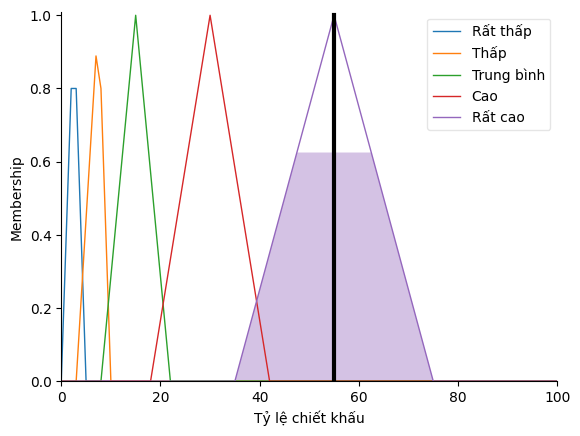

In [8]:
#2.12
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt


# Đánh giá cửa hàng : Thang điểm 0 - 5.0
# Sách quy định: < 4.0 là Thấp, 4.0-4.5 là Trung bình, > 4.5 là Cao
rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Đánh giá cửa hàng')
rating['Thấp'] = fuzz.trimf(rating.universe, [0, 0, 4.0])
rating['Trung bình'] = fuzz.trimf(rating.universe, [3.8, 4.25, 4.6])
rating['Cao'] = fuzz.trimf(rating.universe, [4.4, 5.0, 5.0])

# Khối lượng bán hàng (Sales Volume): Giả sử thang điểm chuẩn hóa 0 - 100 (%)
sales_vol = ctrl.Antecedent(np.arange(0, 101, 1), 'Khối lượng bán hàng')
sales_vol['Thấp'] = fuzz.trimf(sales_vol.universe, [0, 0, 40])
sales_vol['Trung bình'] = fuzz.trimf(sales_vol.universe, [20, 50, 80])
sales_vol['Cao'] = fuzz.trimf(sales_vol.universe, [60, 100, 100])

# Biên lợi nhuận (Profit Margin): Thang 0 - 100 (%)
profit = ctrl.Antecedent(np.arange(0, 101, 1), 'Biên lợi nhuận')
profit['Thấp'] = fuzz.trimf(profit.universe, [0, 0, 30])
profit['Trung bình'] = fuzz.trimf(profit.universe, [20, 50, 80])
profit['Cao'] = fuzz.trimf(profit.universe, [60, 100, 100])

# Sự kiện theo mùa (Seasonal Event): Giả sử thang mức độ 0 - 10
season = ctrl.Antecedent(np.arange(0, 11, 1), 'Sự kiện theo mùa')
season['Không có'] = fuzz.trimf(season.universe, [0, 0, 3])
season['Trung bình'] = fuzz.trimf(season.universe, [2, 5, 8])
season['Cao'] = fuzz.trimf(season.universe, [7, 10, 10])

# Giảm giá của đối thủ (Competitor Discounts): Thang 0 - 100 (%)
comp_discount = ctrl.Antecedent(np.arange(0, 101, 1), 'Giảm giá đối thủ')
comp_discount['Thấp'] = fuzz.trimf(comp_discount.universe, [0, 0, 30])
comp_discount['Trung bình'] = fuzz.trimf(comp_discount.universe, [20, 50, 80])
comp_discount['Cao'] = fuzz.trimf(comp_discount.universe, [60, 100, 100])


# Tỷ lệ chiết khấu (Discount Percentage): 0 - 100%
# Thiết lập đỉnh tam giác dựa theo các khoảng sách cung cấp
discount = ctrl.Consequent(np.arange(0, 101, 1), 'Tỷ lệ chiết khấu')
discount['Rất thấp'] = fuzz.trimf(discount.universe, [0, 2.5, 5])      # 0-5%
discount['Thấp'] = fuzz.trimf(discount.universe, [3, 7.5, 10])         # 5-10%
discount['Trung bình'] = fuzz.trimf(discount.universe, [8, 15, 22])    # 10-20%
discount['Cao'] = fuzz.trimf(discount.universe, [18, 30, 42])          # 20-40%
discount['Rất cao'] = fuzz.trimf(discount.universe, [35, 55, 75])      # 40-70%

rules = [
    ctrl.Rule(rating['Cao'] & sales_vol['Cao'] & profit['Cao'], discount['Rất thấp']),
    ctrl.Rule(rating['Thấp'] & sales_vol['Thấp'] & profit['Cao'], discount['Cao']),
    ctrl.Rule(season['Cao'] & comp_discount['Cao'], discount['Rất cao']),
    ctrl.Rule(rating['Trung bình'] & sales_vol['Trung bình'] & profit['Trung bình'], discount['Trung bình']),
    ctrl.Rule(comp_discount['Thấp'] & profit['Thấp'] & sales_vol['Cao'], discount['Rất thấp']),
    ctrl.Rule(rating['Thấp'] & season['Không có'], discount['Trung bình']),
    ctrl.Rule(sales_vol['Thấp'] & profit['Thấp'], discount['Rất cao'])
]


shopee_ctrl = ctrl.ControlSystem(rules)
shopee_sim = ctrl.ControlSystemSimulation(shopee_ctrl)

shopee_sim.input['Đánh giá cửa hàng'] = 4.3      # Xếp hạng = 4.3 (Trung bình)
shopee_sim.input['Khối lượng bán hàng'] = 50     # Khối lượng = Trung bình (Gán là 50/100)
shopee_sim.input['Biên lợi nhuận'] = 15          # Biên lợi nhuận = Thấp (Gán là 15%)
shopee_sim.input['Sự kiện theo mùa'] = 9         # Sự kiện = Cao (Gán 9/10)
shopee_sim.input['Giảm giá đối thủ'] = 85        # Đối thủ giảm giá = Cao (Gán 85%)


shopee_sim.compute()


print("====== KẾT QUẢ MÔ PHỎNG CHIẾT KHẤU SHOPEE ======")
print(f"Tỷ lệ chiết khấu đề xuất: {shopee_sim.output['Tỷ lệ chiết khấu']:.2f} %")
print("(Sách kỳ vọng mức chiết khấu sẽ rơi vào khoảng Cao: 30-40% do có luật sự kiện mùa cao và đối thủ cao kéo lên mức Rất cao, kết hợp luật Trung bình)")


discount.view(sim=shopee_sim)

====== KẾT QUẢ MÔ PHỎNG CHIẾT KHẤU MẶT HÀNG ĐẶC BIỆT ======
Tỷ lệ chiết khấu đề xuất: 15.00 %
(Giáo trình kỳ vọng kết quả nằm ở mức Trung bình)


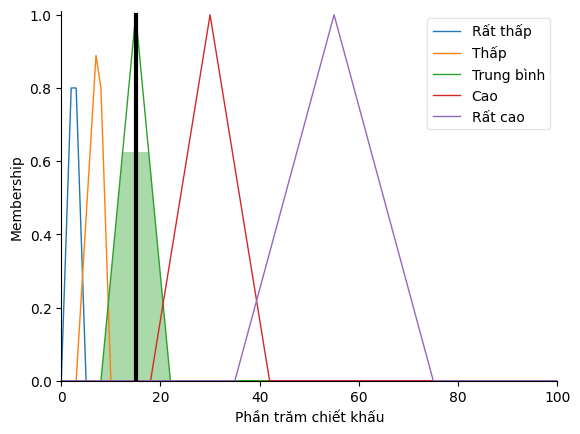

In [6]:
#2.13
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Nhu cầu sản phẩm (Product Demand): 0 - 100
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'Nhu cầu sản phẩm')
demand['Thấp'] = fuzz.trimf(demand.universe, [0, 0, 40])
demand['Trung bình'] = fuzz.trimf(demand.universe, [20, 50, 80])
demand['Cao'] = fuzz.trimf(demand.universe, [60, 100, 100])

# Áp lực định giá của đối thủ (Competitor Pressure): 0 - 100
pressure = ctrl.Antecedent(np.arange(0, 101, 1), 'Áp lực định giá')
pressure['Thấp'] = fuzz.trimf(pressure.universe, [0, 0, 40])
pressure['Trung bình'] = fuzz.trimf(pressure.universe, [20, 50, 80])
pressure['Cao'] = fuzz.trimf(pressure.universe, [60, 100, 100])

# Uy tín cửa hàng (Store Reputation): 0 - 5.0 sao
reputation = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Uy tín cửa hàng')
reputation['Thấp'] = fuzz.trimf(reputation.universe, [0, 0, 4.0])
reputation['Trung bình'] = fuzz.trimf(reputation.universe, [3.8, 4.25, 4.6])
reputation['Cao'] = fuzz.trimf(reputation.universe, [4.4, 5.0, 5.0])

# Biên lợi nhuận (Profit Margin): 0 - 100 (%)
margin = ctrl.Antecedent(np.arange(0, 101, 1), 'Biên lợi nhuận')
margin['Thấp'] = fuzz.trimf(margin.universe, [0, 0, 40])
margin['Trung bình'] = fuzz.trimf(margin.universe, [20, 50, 80])
margin['Cao'] = fuzz.trimf(margin.universe, [60, 100, 100])

# Nhu cầu theo mùa (Seasonal Demand): 0 - 100
season = ctrl.Antecedent(np.arange(0, 101, 1), 'Nhu cầu theo mùa')
season['Không có'] = fuzz.trimf(season.universe, [0, 0, 30])
season['Trung bình'] = fuzz.trimf(season.universe, [20, 50, 80])
season['Cao'] = fuzz.trimf(season.universe, [60, 100, 100])


# Phần trăm chiết khấu (Discount Percentage)
discount = ctrl.Consequent(np.arange(0, 101, 1), 'Phần trăm chiết khấu')
discount['Rất thấp'] = fuzz.trimf(discount.universe, [0, 2.5, 5])      # 0-5%
discount['Thấp'] = fuzz.trimf(discount.universe, [3, 7.5, 10])         # 5-10%
discount['Trung bình'] = fuzz.trimf(discount.universe, [8, 15, 22])    # 10-20% (sách ghi 10-20, test case ghi 15-25, mình lấy trung bình)
discount['Cao'] = fuzz.trimf(discount.universe, [18, 30, 42])          # 20-40%
discount['Rất cao'] = fuzz.trimf(discount.universe, [35, 55, 75])      # 40-70%



rules = [
    ctrl.Rule(demand['Cao'] & pressure['Thấp'] & margin['Thấp'], discount['Rất thấp']),
    ctrl.Rule(demand['Thấp'] & pressure['Cao'] & margin['Cao'], discount['Cao']),
    ctrl.Rule(reputation['Cao'] & margin['Trung bình'] & season['Cao'], discount['Trung bình']),
    ctrl.Rule(pressure['Cao'] & season['Cao'] & margin['Cao'], discount['Rất cao']),
    ctrl.Rule(reputation['Thấp'] & demand['Trung bình'] & margin['Thấp'], discount['Trung bình']),
    ctrl.Rule(demand['Cao'] & season['Không có'] & pressure['Thấp'], discount['Rất thấp']),
    ctrl.Rule(margin['Cao'] & pressure['Trung bình'] & season['Trung bình'], discount['Trung bình']),

    ctrl.Rule(margin['Cao'] & season['Cao'] & pressure['Trung bình'], discount['Trung bình'])
]



strategy_ctrl = ctrl.ControlSystem(rules)
strategy_sim = ctrl.ControlSystemSimulation(strategy_ctrl)

strategy_sim.input['Nhu cầu sản phẩm'] = 85     # Cao
strategy_sim.input['Áp lực định giá'] = 50      # Trung bình
strategy_sim.input['Uy tín cửa hàng'] = 4.2     # Trung bình
strategy_sim.input['Biên lợi nhuận'] = 85       # Cao
strategy_sim.input['Nhu cầu theo mùa'] = 90     # Cao


strategy_sim.compute()


print("====== KẾT QUẢ MÔ PHỎNG CHIẾT KHẤU MẶT HÀNG ĐẶC BIỆT ======")
print(f"Tỷ lệ chiết khấu đề xuất: {strategy_sim.output['Phần trăm chiết khấu']:.2f} %")
print("(Giáo trình kỳ vọng kết quả nằm ở mức Trung bình)")


discount.view(sim=strategy_sim)

====== KẾT QUẢ TỐI ƯU HÓA LOGISTICS ======
Chỉ số số lượng đơn hàng kết hợp: 8.89 (Thiên về mức NHIỀU)
Mức độ ưu tiên giao hàng: 5.00 / 10 (Thiên về mức TRUNG BÌNH)


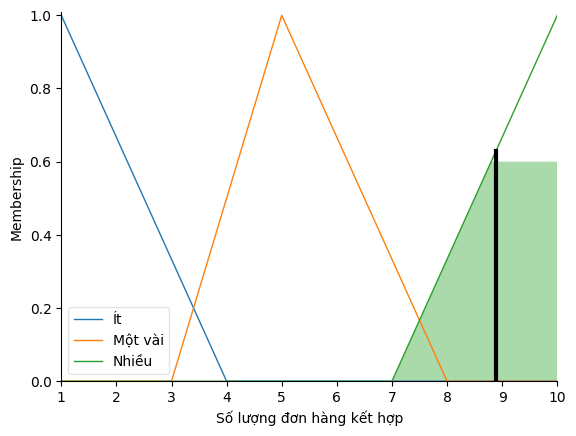

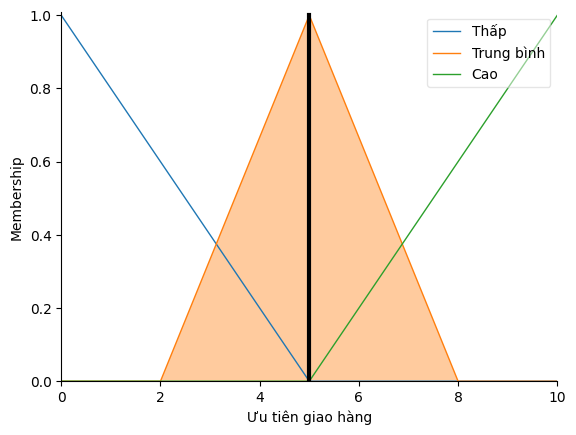

In [7]:
#2.14
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Thang điểm chuẩn hóa: 0 - 10
density = ctrl.Antecedent(np.arange(0, 11, 1), 'Mật độ đơn hàng')
urgency = ctrl.Antecedent(np.arange(0, 11, 1), 'Mức độ khẩn cấp')
load = ctrl.Antecedent(np.arange(0, 11, 1), 'Tải trọng hiện tại')
traffic = ctrl.Antecedent(np.arange(0, 11, 1), 'Tình trạng giao thông')
profit = ctrl.Antecedent(np.arange(0, 11, 1), 'Lợi nhuận')

# Khởi tạo các tập mờ (Thấp, Trung bình, Cao) cho tất cả input
for var in [density, urgency, load, traffic, profit]:
    var['Thấp'] = fuzz.trimf(var.universe, [0, 0, 5])
    var['Trung bình'] = fuzz.trimf(var.universe, [2, 5, 8])
    var['Cao'] = fuzz.trimf(var.universe, [5, 10, 10])



# Số lượng đơn hàng cần kết hợp (Combine): Giả sử thang đo 1 - 10 đơn hàng
combine = ctrl.Consequent(np.arange(1, 11, 1), 'Số lượng đơn hàng kết hợp')
combine['Ít'] = fuzz.trimf(combine.universe, [1, 1, 4])
combine['Một vài'] = fuzz.trimf(combine.universe, [3, 5, 8])
combine['Nhiều'] = fuzz.trimf(combine.universe, [7, 10, 10])

# Ưu tiên giao hàng (Priority): Thang điểm 0 - 10
priority = ctrl.Consequent(np.arange(0, 11, 1), 'Ưu tiên giao hàng')
priority['Thấp'] = fuzz.trimf(priority.universe, [0, 0, 5])
priority['Trung bình'] = fuzz.trimf(priority.universe, [2, 5, 8])
priority['Cao'] = fuzz.trimf(priority.universe, [5, 10, 10])



rules = [
    # LUẬT KẾT HỢP ĐƠN HÀNG
    ctrl.Rule(density['Cao'] & load['Thấp'] & traffic['Thấp'], combine['Nhiều']),
    ctrl.Rule(density['Trung bình'] & traffic['Cao'] & urgency['Trung bình'], combine['Một vài']),
    ctrl.Rule(load['Cao'] & density['Cao'] & profit['Trung bình'], combine['Một vài']), # Sách ghi "Một số", map chung vào "Một vài"
    ctrl.Rule(density['Thấp'] & urgency['Cao'] & traffic['Trung bình'], combine['Một vài']),
    ctrl.Rule(profit['Cao'] & urgency['Cao'] & traffic['Cao'], combine['Một vài']),

    #  LUẬT ƯU TIÊN GIAO HÀNG
    ctrl.Rule(urgency['Cao'] & profit['Cao'], priority['Cao']),
    ctrl.Rule(urgency['Trung bình'] & traffic['Trung bình'], priority['Trung bình']),
    ctrl.Rule(urgency['Thấp'] & density['Cao'] & profit['Thấp'], priority['Thấp']),

    ctrl.Rule(density['Cao'] & load['Thấp'] & traffic['Trung bình'], combine['Nhiều'])
]

logistics_ctrl = ctrl.ControlSystem(rules)
logistics_sim = ctrl.ControlSystemSimulation(logistics_ctrl)

logistics_sim.input['Mật độ đơn hàng'] = 8       # Cao
logistics_sim.input['Mức độ khẩn cấp'] = 5       # Trung bình
logistics_sim.input['Tải trọng hiện tại'] = 2    # Thấp
logistics_sim.input['Tình trạng giao thông'] = 5 # Trung bình
logistics_sim.input['Lợi nhuận'] = 5             # Trung bình


logistics_sim.compute()


print("====== KẾT QUẢ TỐI ƯU HÓA LOGISTICS ======")
print(f"Chỉ số số lượng đơn hàng kết hợp: {logistics_sim.output['Số lượng đơn hàng kết hợp']:.2f} (Thiên về mức NHIỀU)")
print(f"Mức độ ưu tiên giao hàng: {logistics_sim.output['Ưu tiên giao hàng']:.2f} / 10 (Thiên về mức TRUNG BÌNH)")


combine.view(sim=logistics_sim)
priority.view(sim=logistics_sim)